# Grouped leakage protocol if verified relationships exist

Creates new grouped folds only after human/source verification. It does not refit a neural model.

Run the single code cell below with the **Python (skin)** kernel.

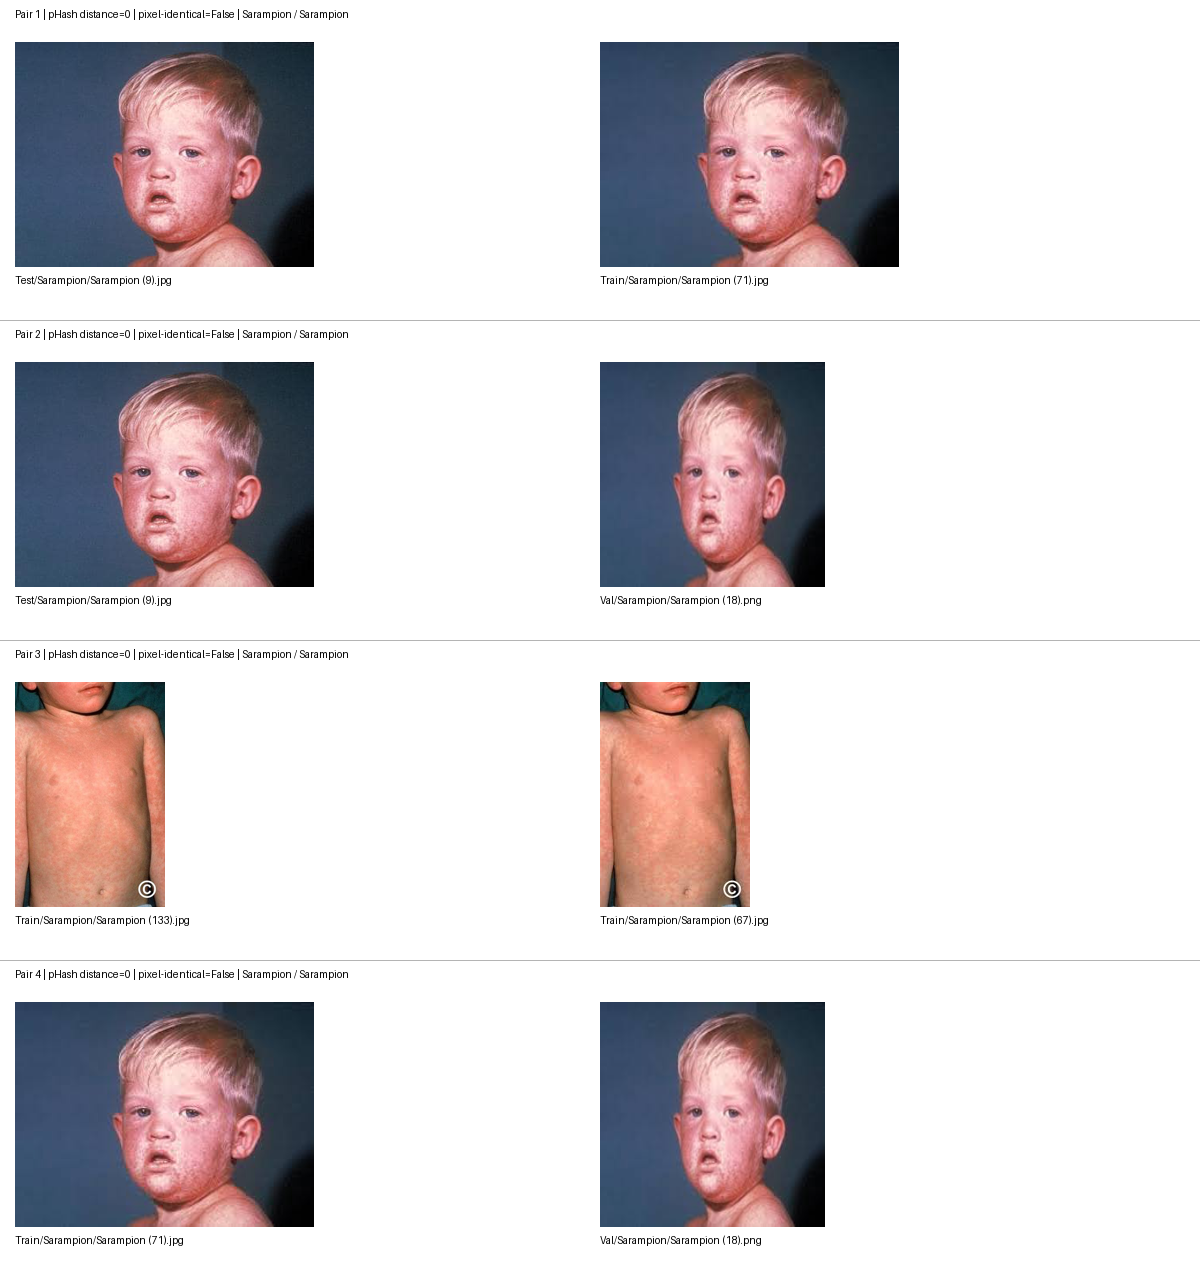

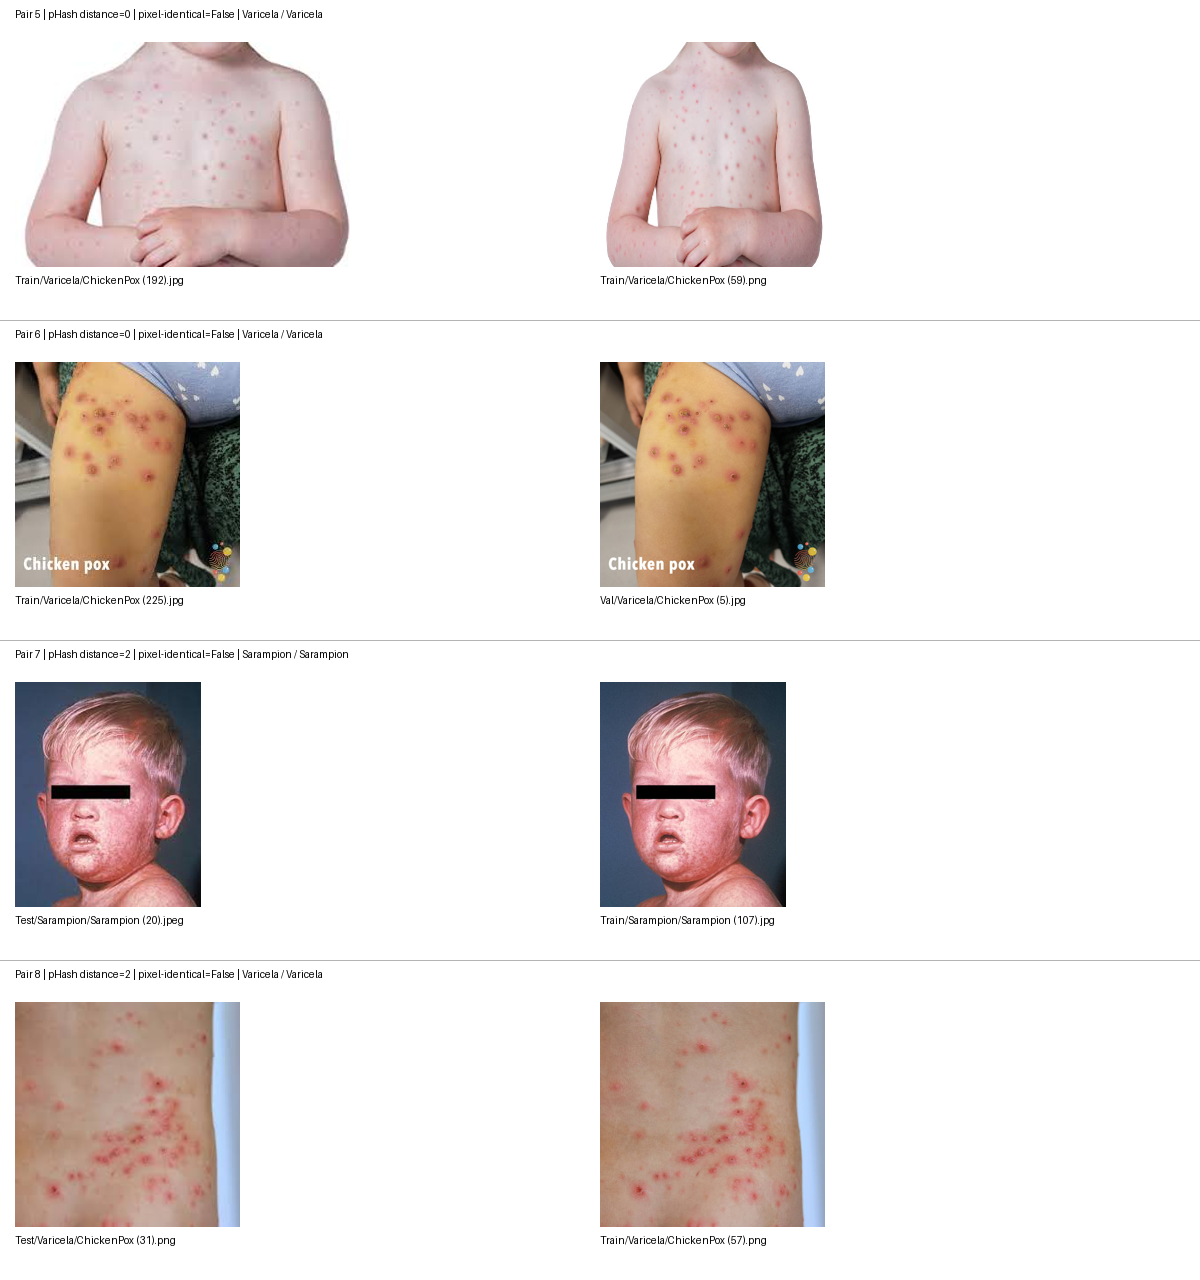

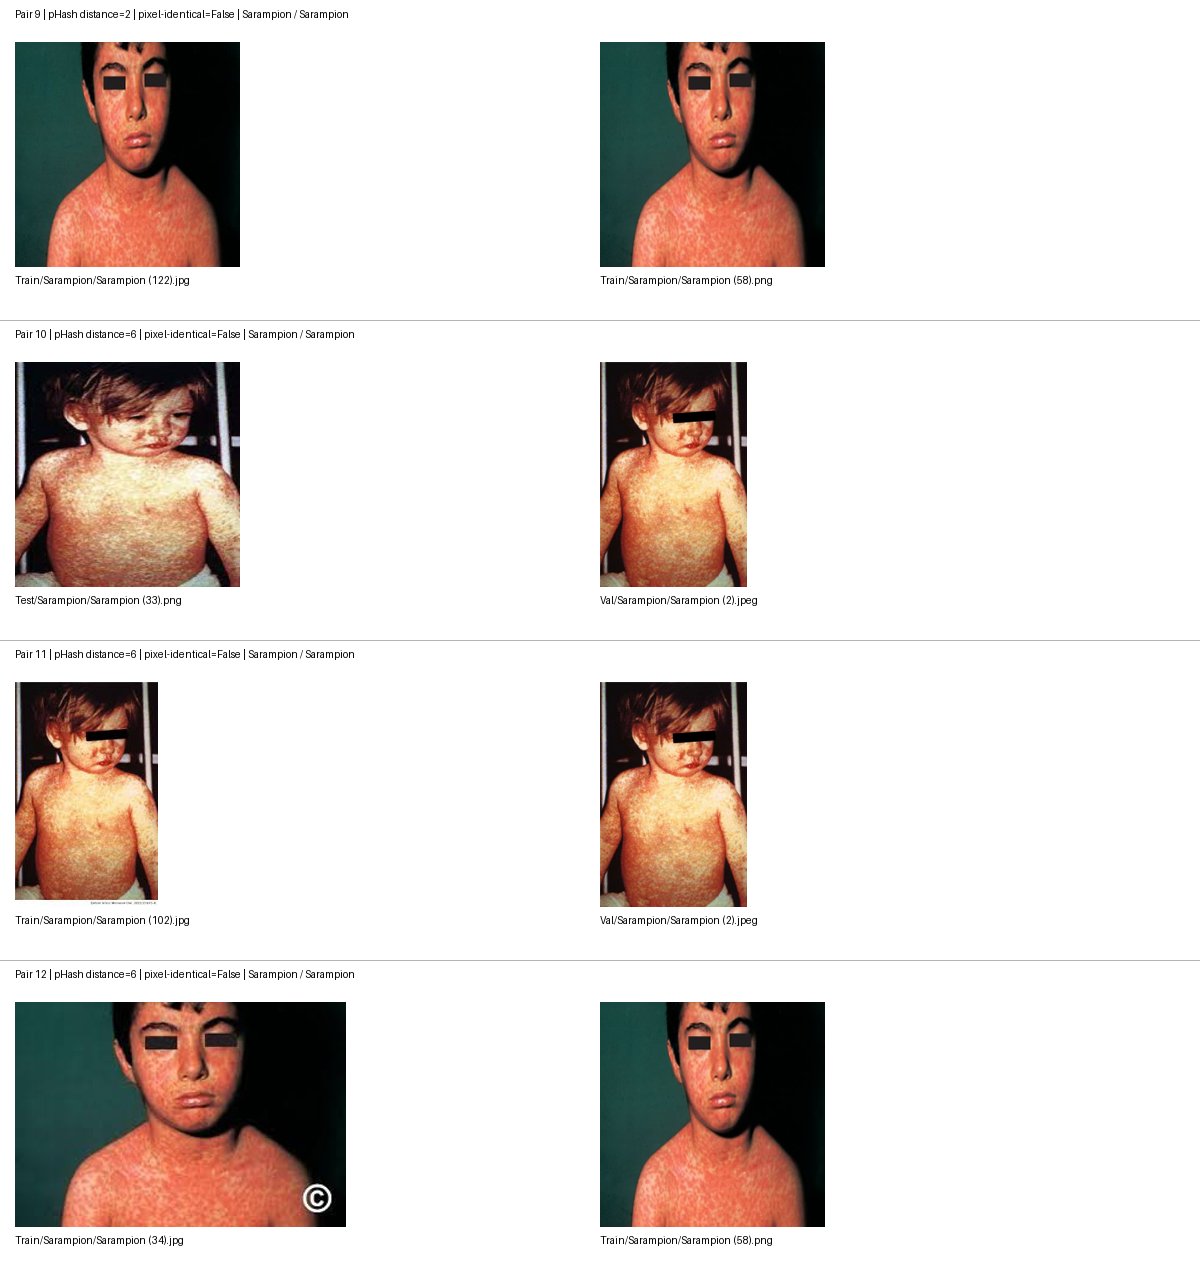

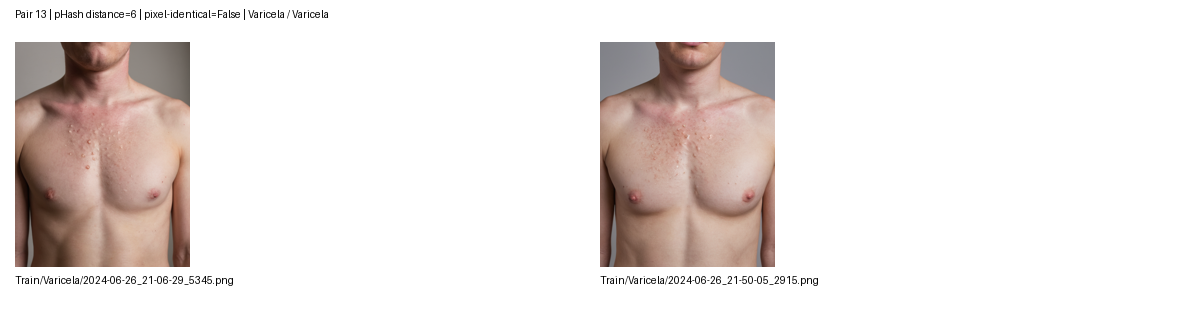

{'archive_wide_candidates': 396, 'archive_wide_exact_pixel_pairs': 16, 'archive_cross_split_exact_pixel_pairs': 2, 'cohort_candidates_requiring_review': 13, 'cohort_exact_pixel_pairs': 0, 'reviewed_yes': 13, 'reviewed_no': 0, 'unresolved': 0, 'review_file': 'D:\\AIUB\\Neural\\A_Comprehensive_Framework_for_Auditing_Demographic_Bias_in_Synthetic_Skin_Disease_Datasets\\revision_package\\runs\\review_revision_run\\reviewed_duplicate_pairs_cohort.csv'}

IMPORTANT: exact cross-split duplicates exist elsewhere in the 2,750-image archive. This cohort-only review does not certify full-archive benchmark independence.
Running: C:\Users\sazib\anaconda3\envs\skin\python.exe D:\AIUB\Neural\A_Comprehensive_Framework_for_Auditing_Demographic_Bias_in_Synthetic_Skin_Disease_Datasets\revision_package\scripts\06_make_grouped_splits.py --metadata D:\AIUB\Neural\A_Comprehensive_Framework_for_Auditing_Demographic_Bias_in_Synthetic_Skin_Disease_Datasets\revision_package\runs\review_revision_run\data_audit\aud

In [3]:
from pathlib import Path
import sys

PACKAGE_DIR_INPUT = Path(r"D:\AIUB\Neural\A_Comprehensive_Framework_for_Auditing_Demographic_Bias_in_Synthetic_Skin_Disease_Datasets\revision_package")
if not PACKAGE_DIR_INPUT.is_dir():
    raise FileNotFoundError(f"revision_package not found: {PACKAGE_DIR_INPUT}")
if str(PACKAGE_DIR_INPUT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR_INPUT))

from pathlib import Path
import textwrap

import pandas as pd
from PIL import Image, ImageDraw, ImageOps
try:
    from IPython.display import Image as NotebookImage, display
except ImportError:
    NotebookImage = None

from notebook_config import DATA_ROOT, RUN_ROOT
from notebook_support import ensure_core_outputs, run_once, write_json

audit_metadata, _ = ensure_core_outputs(RUN_ROOT)
raw_candidates = RUN_ROOT / "data_audit" / "duplicate_candidates_for_review.csv"
metadata = pd.read_csv(audit_metadata, dtype={"sample_id": str})
all_pairs = pd.read_csv(
    raw_candidates, dtype={"sample_id_a": str, "sample_id_b": str}
).fillna("")
metadata_ids = set(metadata["sample_id"].astype(str))
cohort_pairs = all_pairs[
    all_pairs["sample_id_a"].astype(str).isin(metadata_ids)
    & all_pairs["sample_id_b"].astype(str).isin(metadata_ids)
].copy()
cohort_pairs = cohort_pairs.sort_values(
    ["pixel_identical", "phash_distance", "sample_id_a", "sample_id_b"],
    ascending=[False, True, True, True],
).reset_index(drop=True)
cohort_pairs.insert(0, "pair_id", range(1, len(cohort_pairs) + 1))

cohort_candidates = RUN_ROOT / "cohort_duplicate_candidates.csv"
reviewed_pairs = RUN_ROOT / "reviewed_duplicate_pairs_cohort.csv"
review_pages = RUN_ROOT / "duplicate_review_pages"
cohort_pairs.to_csv(cohort_candidates, index=False)

def pair_keys(frame):
    return set(zip(
        frame["sample_id_a"].astype(str),
        frame["sample_id_b"].astype(str),
    ))

if not reviewed_pairs.exists():
    cohort_pairs.to_csv(reviewed_pairs, index=False)
    print(f"Created a cohort-only review file with {len(cohort_pairs)} pairs: {reviewed_pairs}")

reviewed = pd.read_csv(
    reviewed_pairs, dtype={"sample_id_a": str, "sample_id_b": str}
).fillna("")
if pair_keys(reviewed) != pair_keys(cohort_pairs) or len(reviewed) != len(cohort_pairs):
    raise ValueError(
        "The review file does not exactly match the current cohort candidates. "
        f"Preserve it for provenance, then rename it and rerun this cell: {reviewed_pairs}"
    )
allowed_status = reviewed["verified_related"].astype(str).str.strip().str.lower()
if not allowed_status.isin(["yes", "no", ""]).all():
    raise ValueError("verified_related may contain only yes, no, or blank")

def safe_image(sample_id):
    root = DATA_ROOT.resolve()
    path = (DATA_ROOT / Path(sample_id)).resolve()
    if not path.is_relative_to(root) or not path.is_file():
        raise FileNotFoundError(f"Invalid review image path: {sample_id}")
    with Image.open(path) as source:
        return source.convert("RGB").copy()

def make_review_pages(frame):
    review_pages.mkdir(parents=True, exist_ok=True)
    for old_page in review_pages.glob("page_*.png"):
        old_page.unlink()
    page_paths = []
    per_page, page_width, row_height = 4, 1200, 320
    for start in range(0, len(frame), per_page):
        block = frame.iloc[start:start + per_page]
        canvas = Image.new("RGB", (page_width, row_height * len(block)), "white")
        draw = ImageDraw.Draw(canvas)
        for row_number, (_, row) in enumerate(block.iterrows()):
            y = row_number * row_height
            heading = (
                f"Pair {int(row['pair_id'])} | pHash distance={row['phash_distance']} | "
                f"pixel-identical={row['pixel_identical']} | {row['label_a']} / {row['label_b']}"
            )
            draw.text((15, y + 8), heading, fill="black")
            for column, sample_column in enumerate(["sample_id_a", "sample_id_b"]):
                sample_id = str(row[sample_column])
                image = ImageOps.contain(safe_image(sample_id), (540, 225))
                x = 15 + column * 585
                canvas.paste(image, (x, y + 42))
                caption = "\n".join(textwrap.wrap(sample_id, width=72))
                draw.multiline_text((x, y + 274), caption, fill="black", spacing=2)
            if row_number:
                draw.line((0, y, page_width, y), fill=(180, 180, 180), width=1)
        page = review_pages / f"page_{start // per_page + 1:02d}.png"
        canvas.save(page)
        page_paths.append(page)
    return page_paths

pages = make_review_pages(cohort_pairs) if len(cohort_pairs) else []
for page in pages:
    if NotebookImage is None:
        print(page)
    else:
        display(NotebookImage(filename=str(page)))

status = (
    reviewed["verified_related"].astype(str).str.strip().str.lower()
    if len(reviewed) else pd.Series(dtype=str)
)
unresolved = int(status.eq("").sum())
identity_fields = [
    field for field in ["patient_id", "case_id", "parent_id", "acquisition_session"]
    if field in metadata
]
has_verified_ids = any(
    metadata[field].notna().any()
    and (~metadata[field].astype(str).str.strip().str.lower().isin(
        ["", "unknown", "missing", "nan"]
    )).any()
    for field in identity_fields
)
yes_pairs = int(status.eq("yes").sum())
archive_exact = all_pairs["pixel_identical"].astype(str).str.lower().eq("true")
archive_cross_split = (
    all_pairs["archive_split_a"].astype(str)
    != all_pairs["archive_split_b"].astype(str)
)

summary = {
    "archive_wide_candidates": int(len(all_pairs)),
    "archive_wide_exact_pixel_pairs": int(archive_exact.sum()),
    "archive_cross_split_exact_pixel_pairs": int((archive_exact & archive_cross_split).sum()),
    "cohort_candidates_requiring_review": int(len(cohort_pairs)),
    "cohort_exact_pixel_pairs": int(
        cohort_pairs["pixel_identical"].astype(str).str.lower().eq("true").sum()
    ) if len(cohort_pairs) else 0,
    "reviewed_yes": yes_pairs,
    "reviewed_no": int(status.eq("no").sum()),
    "unresolved": unresolved,
    "review_file": str(reviewed_pairs),
}
write_json(RUN_ROOT / "duplicate_review_summary.json", summary)
print(summary)
if int((archive_exact & archive_cross_split).sum()):
    print(
        "\nIMPORTANT: exact cross-split duplicates exist elsewhere in the 2,750-image archive. "
        "This cohort-only review does not certify full-archive benchmark independence."
    )

if unresolved:
    print(f"\nSTOP: inspect the pages above, fill yes/no for the {unresolved} blank rows in:")
    print(reviewed_pairs)
    print("Use yes only for visually/source-verified same images or related variants; pHash similarity alone is not enough.")
    print("Save the CSV, then rerun this same cell.")
elif yes_pairs == 0 and not has_verified_ids:
    print("\nNo candidate was verified as related, and no patient/case identifiers exist.")
    print("Do not claim patient independence; report no verified cohort duplicate pair, with residual lineage risk.")
else:
    grouped_dir = run_once(
        "06_make_grouped_splits.py",
        ["--metadata", str(audit_metadata), "--reviewed-pairs", str(reviewed_pairs)],
        RUN_ROOT / "grouped_protocol",
        [
            "grouped_fold_manifest.csv",
            "grouped_fold_counts.csv",
            "metadata_with_clusters.csv",
            "protocol.json",
        ],
    )
    print(pd.read_csv(grouped_dir / "grouped_fold_counts.csv").to_string(index=False))
    print("\nThese are NEW grouped folds. Run notebook 03 afterward; it detects and uses them automatically.")
